In [11]:
#Get California Housing Dataset

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [12]:
housing_df = pd.DataFrame(housing["data"],columns=housing["feature_names"])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [13]:
housing_df["MedHouseVal"] = housing["target"]
housing_df["target"] = housing["target"]

In [14]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,3.422


In [15]:
housing_df = housing_df.drop("MedHouseVal",axis=1
                            )

In [16]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
#Import algorithm
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor



#set up random seed

np.random.seed(42)

#Create the data

X = housing_df.drop("target",axis=1)
y = housing_df["target"]

# Split the data into test and train
X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.2)

# Instantiate and Fit the model (On the training set)

model_ridge = Ridge()
model_lasso = Lasso()
model_elastic = ElasticNet()
model_svr = svm.SVR()
model_rfreg = RandomForestRegressor()
model_ridge.fit(X_train,y_train)
model_lasso.fit(X_train, y_train)
model_elastic.fit(X_train,y_train)
model_svr.fit(X_train,y_train)
model_rfreg.fit(X_train,y_train)


# Score of the model
model_ridge.score(X_test,y_test)



0.5758549611440125

In [18]:
model_lasso.score(X_test,y_test)

0.2841671821008396

In [19]:
model_elastic.score(X_test,y_test)

0.41655189098028234

In [20]:
model_svr.score(X_test,y_test)

-0.016485360107176605

In [21]:
model_rfreg.score(X_test,y_test)

0.8062221288310311

### 2.2 Using machine learning model based on classification dataset

Consulting the map and it says to try `LineanSVC`

In [23]:
heart_disease = pd.read_csv("data/heart-disease.csv")

In [24]:
from sklearn.svm import LinearSVC

# Random Seed

np.random.seed(42)

# Make the data

X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

In [25]:
# test and train data split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
model_SVC = LinearSVC()
model_SVC.fit(X_train,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [27]:
model_SVC.score(X_test,y_test)

0.8688524590163934

In [28]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

model_rfc = RandomForestClassifier()
model_rfc.fit(X_train, y_train)

model_rfc.score(X_test, y_test)

0.8360655737704918

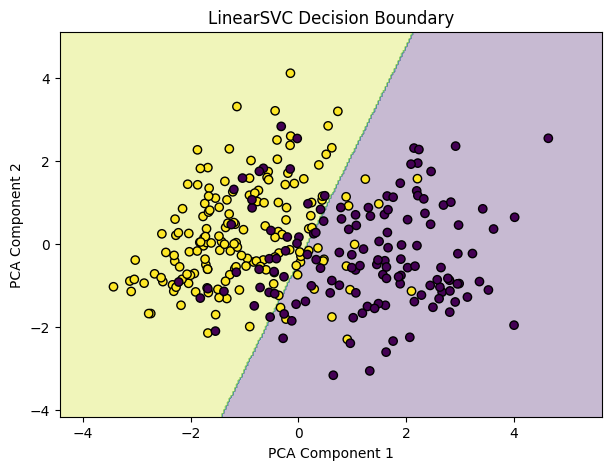

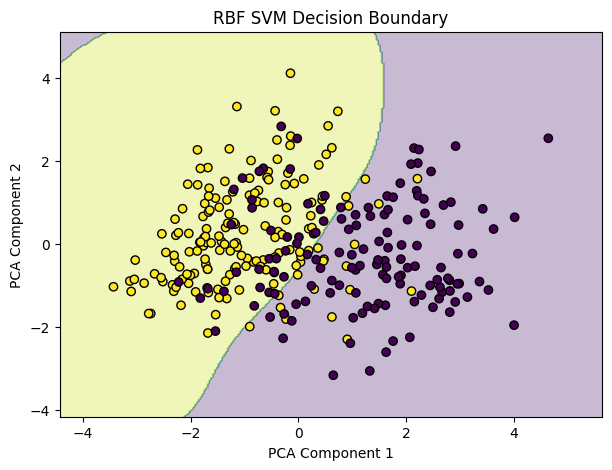

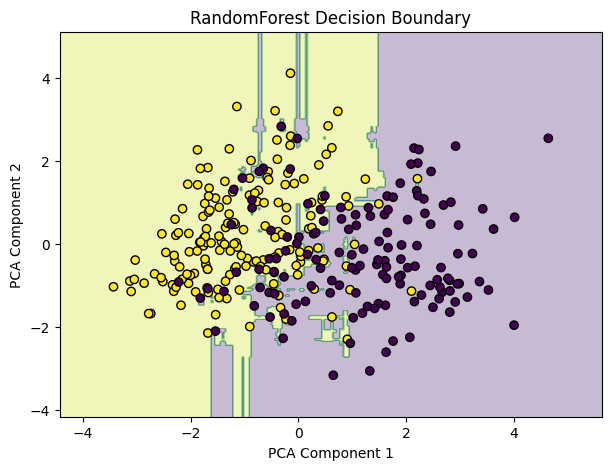

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# 2. Scale + PCA to 2D for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Models
models = {
    "LinearSVC": LinearSVC(max_iter=10000, random_state=42),
    "RBF SVM": SVC(kernel="rbf", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 4. Plot decision boundaries
for name, model in models.items():
    model.fit(X_train, y_train)

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors="k")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"{name} Decision Boundary")
    plt.show()